# Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from scipy.stats import skew, ttest_ind
from functions import plot
from statsmodels.stats.multitest import multipletests
import dash_bio
from adjustText import adjust_text
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Variables

In [3]:
log_trans = True

# Format data

In [4]:
df_org = pd.read_excel("../data/unformated/Daten_Label_24hWt.xlsx", sheet_name="formatted")
rows_unl = [i for i in range(len(df_org)) if i % 2 == 0]
rows_l = [i for i in range(len(df_org)) if i % 2 != 0]
df = df_org.drop(rows_l, axis=0)
df_l = df_org.drop(rows_unl, axis=0)

In [5]:
# add labeled values as new columns
cols = df_org.columns[1:]
for col in cols:
    df[f"{col}_l"] = df_l[col].values

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l,exp2_37deg_4_l,exp4_22deg_1_l,exp4_22deg_2_l,exp4_22deg_3_l,exp4_22deg_4_l,exp4_37deg_1_l,exp4_37deg_2_l,exp4_37deg_3_l,exp4_37deg_4_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.297905,1.413610,2.152663,2.088974,1.241209,1.523959,10.029840,15.876957,14.942153,10.288102
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,4.607286,4.431282,3.054066,3.394669,2.110951,2.512315,31.621042,33.167724,26.167475,24.345149
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.312451,0.359753,4.698023,4.268724,2.673547,3.430581,7.514651,9.460271,11.039339,6.770959
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.556659,0.517282,4.570194,4.422733,3.048503,2.931791,9.367357,9.167949,8.102832,7.341369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000000,0.000000,1.440343,1.202063,0.000000,0.042314,0.000000,0.685638,1.190872,0.000000
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.003247,0.000000,0.000000,0.000000,0.000000,0.020399,0.023651,0.000000,0.000000,0.000000
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Preprocessing

## Add labeled and unlabeled

In [6]:
for col in [c for c in df.columns[1:] if "_l" not in c]:
    col_l = col + "_l"
    df[f"{"sum_" + col}"] = df[[col, col_l]].sum(axis=1)

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.847428,2.091799,7.087813,6.504548,5.155614,5.702898,13.870321,20.558192,18.960797,13.915158
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.037791,0.019042,0.199781,0.077731,0.081558,0.494038,0.138884,3.530519,0.144430,0.295671
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,7.572767,7.444120,11.740640,11.545599,9.090843,9.388558,43.796729,46.595970,37.556787,33.917899
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.692879,0.760974,17.886067,15.990483,12.473368,12.834583,14.013776,14.818631,16.048410,11.839081
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,1.112527,1.047803,15.199035,13.416505,12.013007,10.146587,16.792512,18.227648,17.536853,14.076387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,5.814376,7.037880,83.315002,76.042296,75.521128,86.881725,63.386669,69.381603,80.985892,60.190054
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.100365,0.121930,3.175120,2.792694,3.413205,3.687361,2.376625,2.593236,3.722366,2.424922
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [7]:
df.to_csv("test.csv", index=False)

## Replace zero values
- replace zero values with half minimum value, because log(0) not possible

In [8]:
half_min = np.min([val for val in df.filter(regex=r"^(?!.*compound).*$").values.flatten() if val != 0]) / 2
print("Half minimum:", half_min)

for col in df.columns:
    if col == "compound":
        continue
    
    if "sum" in col:
        #print(col)
        df[col] = df[col].replace(0, half_min)

df

Half minimum: 4.0672700112186134e-05


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.847428,2.091799,7.087813,6.504548,5.155614,5.702898,13.870321,20.558192,18.960797,13.915158
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.037791,0.019042,0.199781,0.077731,0.081558,0.494038,0.138884,3.530519,0.144430,0.295671
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,7.572767,7.444120,11.740640,11.545599,9.090843,9.388558,43.796729,46.595970,37.556787,33.917899
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.692879,0.760974,17.886067,15.990483,12.473368,12.834583,14.013776,14.818631,16.048410,11.839081
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,1.112527,1.047803,15.199035,13.416505,12.013007,10.146587,16.792512,18.227648,17.536853,14.076387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,5.814376,7.037880,83.315002,76.042296,75.521128,86.881725,63.386669,69.381603,80.985892,60.190054
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.100365,0.121930,3.175120,2.792694,3.413205,3.687361,2.376625,2.593236,3.722366,2.424922
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041


## Relative values

In [9]:
cols = [c for c in df.columns[1:] if "sum" in c]


for exp in ["exp2", "exp4"]:
    for deg in ["22deg", "37deg"]:
        df_exp = df.filter(regex=rf"sum_{exp}_{deg}")
        summe = np.sum(df_exp.values.flatten())

        for col in df_exp.columns:
            df[col] = [val / summe for val in df[col].values]

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,3.604114e-03,4.080851e-03,1.590098e-03,1.459247e-03,1.156623e-03,1.279402e-03,3.221527e-03,4.774854e-03,4.403843e-03,3.231941e-03
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,7.372521e-05,3.714794e-05,4.481936e-05,1.743830e-05,1.829696e-05,1.108337e-04,3.225734e-05,8.199999e-04,3.354544e-05,6.867274e-05
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,1.477357e-02,1.452260e-02,2.633925e-03,2.590168e-03,2.039462e-03,2.106253e-03,1.017225e-02,1.082240e-02,8.722956e-03,7.877786e-03
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,1.351725e-03,1.484570e-03,4.012605e-03,3.587345e-03,2.798307e-03,2.879342e-03,3.254846e-03,3.441782e-03,3.727411e-03,2.749750e-03
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,2.170409e-03,2.044140e-03,3.409789e-03,3.009892e-03,2.695028e-03,2.276311e-03,3.900236e-03,4.233561e-03,4.073117e-03,3.269388e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.934762e-08,7.934762e-08,9.124615e-09,9.124615e-09,9.124615e-09,9.124615e-09,9.446659e-09,9.446659e-09,9.446659e-09,9.446659e-09
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,1.134316e-02,1.373007e-02,1.869110e-02,1.705952e-02,1.694260e-02,1.949126e-02,1.472221e-02,1.611460e-02,1.880982e-02,1.397977e-02
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,1.958005e-04,2.378702e-04,7.123144e-04,6.265200e-04,7.657269e-04,8.272318e-04,5.519960e-04,6.023062e-04,8.645584e-04,5.632133e-04
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.934762e-08,7.934762e-08,9.124615e-09,9.124615e-09,9.124615e-09,9.124615e-09,9.446659e-09,9.446659e-09,9.446659e-09,9.446659e-09


In [10]:
df.filter(regex="sum_exp4.*37deg").to_numpy().sum()

np.float64(0.9999999999999998)

## log Transformation

In [11]:
if log_trans == True:
    rel_cols = [c for c in df.columns if "sum" in c]
    print(rel_cols)

    for col in rel_cols:
        df[col] = np.log(df[col].values)

df

['sum_exp2_22deg_1', 'sum_exp2_22deg_2', 'sum_exp2_22deg_3', 'sum_exp2_22deg_4', 'sum_exp2_37deg_1', 'sum_exp2_37deg_2', 'sum_exp2_37deg_3', 'sum_exp2_37deg_4', 'sum_exp4_22deg_1', 'sum_exp4_22deg_2', 'sum_exp4_22deg_3', 'sum_exp4_22deg_4', 'sum_exp4_37deg_1', 'sum_exp4_37deg_2', 'sum_exp4_37deg_3', 'sum_exp4_37deg_4']


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp2_37deg_3,sum_exp2_37deg_4,sum_exp4_22deg_1,sum_exp4_22deg_2,sum_exp4_22deg_3,sum_exp4_22deg_4,sum_exp4_37deg_1,sum_exp4_37deg_2,sum_exp4_37deg_3,sum_exp4_37deg_4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-5.625679,-5.501450,-6.443960,-6.529835,-6.762251,-6.661362,-5.737900,-5.344392,-5.425278,-5.734672
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-9.515166,-10.200602,-10.012870,-10.956842,-10.908776,-9.107480,-10.341765,-7.106206,-10.302610,-9.586158
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-4.214915,-4.232049,-5.939280,-5.956032,-6.195069,-6.162845,-4.588092,-4.526137,-4.741797,-4.843708
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-6.606374,-6.512630,-5.518315,-5.630343,-5.878741,-5.850193,-5.727610,-5.671766,-5.592042,-5.896245
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-6.132840,-6.192778,-5.681105,-5.805851,-5.916347,-6.085199,-5.546718,-5.464712,-5.503347,-5.723153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-16.349427,-16.349427,-18.512290,-18.512290,-18.512290,-18.512290,-18.477605,-18.477605,-18.477605,-18.477605
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-4.479140,-4.288167,-3.979708,-4.071047,-4.077924,-3.937789,-4.218398,-4.128030,-3.973376,-4.270144
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-8.538414,-8.343786,-7.246991,-7.375330,-7.174685,-7.097426,-7.501970,-7.414745,-7.053292,-7.481852
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-16.349427,-16.349427,-18.512290,-18.512290,-18.512290,-18.512290,-18.477605,-18.477605,-18.477605,-18.477605


## Statistics

### Mean and Std

In [12]:
# means per experiment and condition
groups = ["sum_exp2_22deg", "sum_exp2_37deg", "sum_exp4_22deg", "sum_exp4_37deg"]

for g in groups:
    df[f"mean_{g}"] = df.filter(regex=g).mean(axis=1)
    df[f"sd_{g}"] = df.filter(regex=g).std(axis=1)

In [13]:
# # mean per condition
# for f, g in zip([r"^sum_exp\d_22deg", r"^sum_exp\d_22deg"], ["all_22deg", "all_37deg"]):
#     df[f"mean_{g}"] = df.filter(regex=f).mean(axis=1)
#     df[f"sd_{g}"] = df.filter(regex=f).std(axis=1, ddof=1)

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,sum_exp4_37deg_3,sum_exp4_37deg_4,mean_sum_exp2_22deg,sd_sum_exp2_22deg,mean_sum_exp2_37deg,sd_sum_exp2_37deg,mean_sum_exp4_22deg,sd_sum_exp4_22deg,mean_sum_exp4_37deg,sd_sum_exp4_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-5.425278,-5.734672,-6.362650,0.084257,-5.550311,0.059035,-6.599352,0.121820,-5.560560,0.178041
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-10.302610,-9.586158,-14.836871,2.903952,-9.757175,0.301133,-10.246492,0.757487,-9.334185,1.321026
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-4.741797,-4.843708,-5.946942,0.208879,-4.295003,0.071904,-6.063307,0.116361,-4.674934,0.125137
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-5.592042,-5.896245,-5.596818,0.088864,-6.608856,0.066664,-5.719398,0.150717,-5.721916,0.111586
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-5.503347,-5.723153,-6.130194,0.235836,-6.243514,0.084530,-5.872125,0.148524,-5.559482,0.098848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-18.477605,-18.477605,-16.513468,0.000000,-16.349427,0.000000,-18.512290,0.000000,-18.477605,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-3.973376,-4.270144,-4.607418,0.067550,-4.404224,0.071068,-4.016617,0.059786,-4.147487,0.112657
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-7.053292,-7.481852,-8.689810,0.131342,-8.397060,0.087121,-7.223608,0.102325,-7.362965,0.181683
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-18.477605,-18.477605,-16.513468,0.000000,-16.349427,0.000000,-18.512290,0.000000,-18.477605,0.000000


### T-test

In [14]:
## ttest between 22deg and 37deg per experiment
for control, heat, label in [[r"^sum_exp2_22deg_\d+", r"^sum_exp2_37deg_\d+", "exp2"], [r"^sum_exp4_22deg_\d+", r"^sum_exp4_37deg_\d+", "exp4"]]:
    control_vals = df.filter(regex=control)
    heat_vals = df.filter(regex=heat)

    t_stat, p_val = ttest_ind(control_vals, heat_vals, axis=1)

    var_control = control_vals.var(axis=1).values
    var_heat = heat_vals.var(axis=1).values

    # invalid tests
    invalid = (
        (var_control == 0) |
        (var_heat == 0) |
        np.isinf(t_stat) |
        np.isnan(t_stat)
    )

    # set invalid tests to NaN
    t_stat[invalid] = np.nan
    p_val[invalid] = np.nan

    # BH correction ONLY on valid p-values
    p_val_adj = np.full_like(p_val, np.nan)
    valid_mask = ~np.isnan(p_val)

    if valid_mask.sum() > 0:
        p_val_adj[valid_mask] = multipletests(
            p_val[valid_mask],
            method="fdr_bh"
        )[1]

    df[f"t_stat_{label}"] = t_stat
    df[f"p_val_{label}"] = p_val
    df[f"p_val_adj_{label}"] = p_val_adj

df

c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,mean_sum_exp4_22deg,sd_sum_exp4_22deg,mean_sum_exp4_37deg,sd_sum_exp4_37deg,t_stat_exp2,p_val_exp2,p_val_adj_exp2,t_stat_exp4,p_val_exp4,p_val_adj_exp4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-6.599352,0.121820,-5.560560,0.178041,-13.676146,0.000009,0.000186,-8.340296,0.000161,0.002074
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-10.246492,0.757487,-9.334185,1.321026,-3.013605,0.023591,0.041992,-1.037674,0.339420,0.440298
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-6.063307,0.116361,-4.674934,0.125137,-12.952171,0.000013,0.000186,-14.072814,0.000008,0.000317
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-5.719398,0.150717,-5.721916,0.111586,15.779142,0.000004,0.000152,0.023255,0.982201,0.992906
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-5.872125,0.148524,-5.559482,0.098848,0.783452,0.463156,0.482726,-3.035219,0.022943,0.051787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-18.512290,0.000000,-18.477605,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-4.016617,0.059786,-4.147487,0.112657,-3.589470,0.011511,0.023022,1.777303,0.125846,0.194937
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-7.223608,0.102325,-7.362965,0.181683,-3.217179,0.018202,0.034537,1.157570,0.291034,0.389690
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-18.512290,0.000000,-18.477605,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
## ttest between exp2 and exp4 per condition
for exp2, exp4, label in [[r"^sum_exp2_22deg_\d+", r"^sum_exp4_22deg_\d+", "22deg"], [r"^sum_exp2_37deg_\d+", r"^sum_exp4_37deg_\d+", "37deg"]]:
    exp2_vals = df.filter(regex=exp2)
    exp4_vals = df.filter(regex=exp4)

    t_stat, p_val = ttest_ind(exp2_vals, exp4_vals, axis=1)

    var_exp2 = exp2_vals.var(axis=1).values
    var_exp4 = exp4_vals.var(axis=1).values

    # invalid tests
    invalid = (
        (var_exp2 == 0) |
        (var_exp4 == 0) |
        np.isinf(t_stat) |
        np.isnan(t_stat)
    )

    # set invalid to NaN
    t_stat[invalid] = np.nan
    p_val[invalid] = np.nan

    # BH correction only on valid p-values
    p_val_adj = np.full_like(p_val, np.nan)
    valid_mask = ~np.isnan(p_val)

    if valid_mask.sum() > 0:
        p_val_adj[valid_mask] = multipletests(
            p_val[valid_mask],
            method="fdr_bh"
        )[1]

    df[f"t_stat_{label}"] = t_stat
    df[f"p_val_{label}"] = p_val
    df[f"p_val_adj_{label}"] = p_val_adj
df

c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj_exp2,t_stat_exp4,p_val_exp4,p_val_adj_exp4,t_stat_22deg,p_val_22deg,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.000186,-8.340296,0.000161,0.002074,2.767901,3.251256e-02,0.049806,0.094643,0.927680,0.927680
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.041992,-1.037674,0.339420,0.440298,-2.649267,3.806587e-02,0.054815,-0.540729,0.608168,0.625796
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.000186,-14.072814,0.000008,0.000317,0.842942,4.315747e-01,0.456961,4.559580,0.003853,0.006079
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.000152,0.023255,0.982201,0.992906,1.213476,2.705455e-01,0.314182,-11.818698,0.000022,0.000225
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.482726,-3.035219,0.022943,0.051787,-1.603787,1.598822e-01,0.195111,-9.109320,0.000098,0.000436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.023022,1.777303,0.125846,0.194937,-11.343896,2.810270e-05,0.000225,-3.338450,0.015642,0.021776
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.034537,1.157570,0.291034,0.389690,-15.252801,5.013815e-06,0.000052,-8.889238,0.000113,0.000441
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


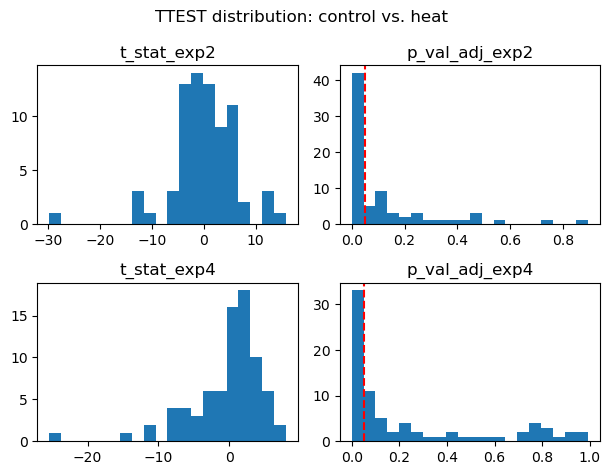

In [16]:
fig, axs = plot(2, 2, "TTEST distribution: control vs. heat", df, [["t_stat_exp2", "p_val_adj_exp2"], ["t_stat_exp4", "p_val_adj_exp4"]], 20)
axs[0, 1].axvline(0.05, linestyle="--", color="red")
axs[1, 1].axvline(0.05, linestyle="--", color="red")

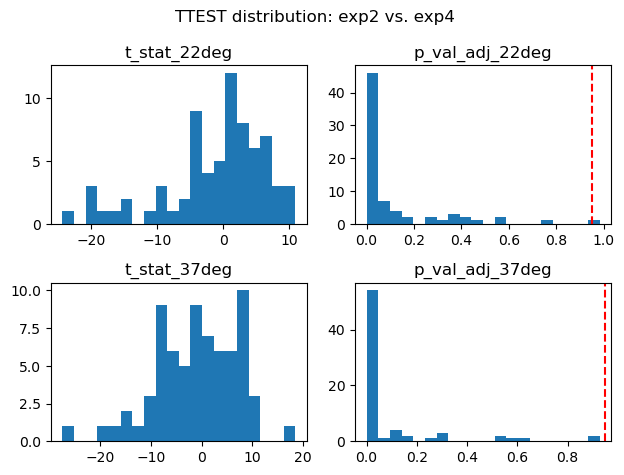

In [17]:
fig, axs = plot(2, 2, "TTEST distribution: exp2 vs. exp4", df, [["t_stat_22deg", "p_val_adj_22deg"], ["t_stat_37deg", "p_val_adj_37deg"]], 20)
axs[0, 1].axvline(0.95, linestyle="--", color="red")
axs[1, 1].axvline(0.95, linestyle="--", color="red")

-> no significant differences expected between exp2 and exp4

### Fold change

In [18]:
## fold change between 22deg and 37deg
df["log2_fc_exp2"] = df["mean_sum_exp2_37deg"] - df["mean_sum_exp2_22deg"] # -> FC = 1 means under heat stress compound is twice as high 
df["log2_fc_exp4"] = df["mean_sum_exp4_37deg"] - df["mean_sum_exp4_22deg"]
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_exp4,p_val_adj_exp4,t_stat_22deg,p_val_22deg,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg,log2_fc_exp2,log2_fc_exp4
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.000161,0.002074,2.767901,3.251256e-02,0.049806,0.094643,0.927680,0.927680,0.812338,1.038791
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.339420,0.440298,-2.649267,3.806587e-02,0.054815,-0.540729,0.608168,0.625796,5.079696,0.912307
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.000008,0.000317,0.842942,4.315747e-01,0.456961,4.559580,0.003853,0.006079,1.651939,1.388373
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.982201,0.992906,1.213476,2.705455e-01,0.314182,-11.818698,0.000022,0.000225,-1.012038,-0.002518
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.022943,0.051787,-1.603787,1.598822e-01,0.195111,-9.109320,0.000098,0.000436,-0.113320,0.312643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.164041,0.034685
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.125846,0.194937,-11.343896,2.810270e-05,0.000225,-3.338450,0.015642,0.021776,0.203195,-0.130870
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.291034,0.389690,-15.252801,5.013815e-06,0.000052,-8.889238,0.000113,0.000441,0.292750,-0.139357
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.164041,0.034685


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


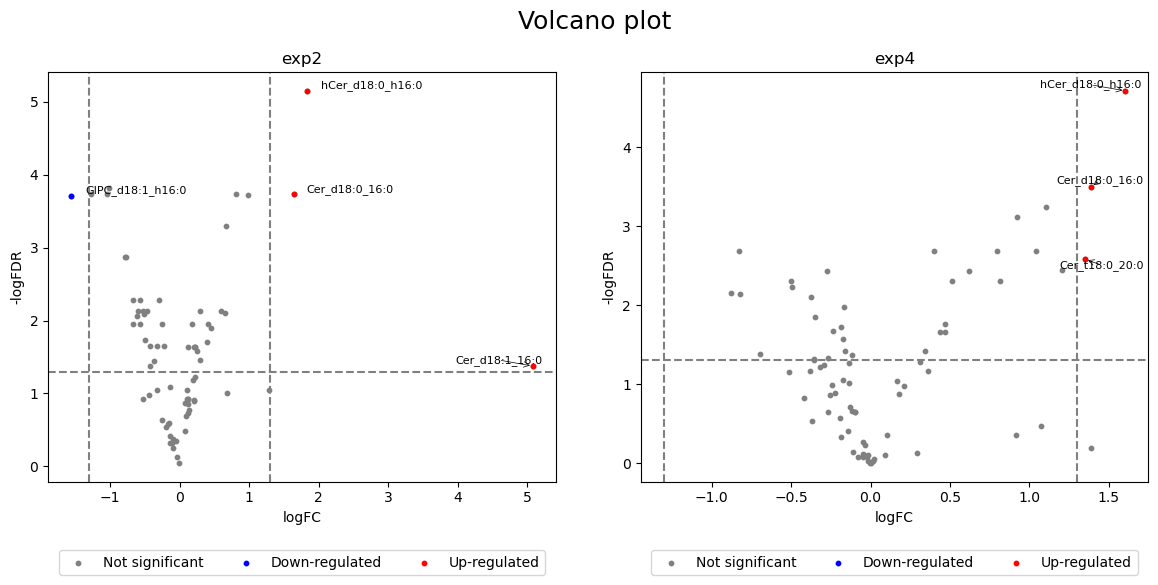

In [19]:
size = 10
signif = 0.05
level = -np.log10(signif)

fig, axs = plt.subplots(1, 2, figsize=(12,6))

for i, exp in enumerate(["exp2", "exp4"]):
    df_volcano = df[["compound", f"log2_fc_{exp}", f"p_val_adj_{exp}"]]
    df_volcano.columns = ["compounds", "log2_fc", "p_val_adj"]

    axs[i].scatter(x=df_volcano["log2_fc"], y=df_volcano["p_val_adj"].apply(lambda x:-np.log10(x)), s=size, label="Not significant", color="grey")

    # highlight down- or up- regulated metabolites
    down = df_volcano[(df_volcano["log2_fc"] <= level * -1) & (df_volcano["p_val_adj"] <= signif)]
    up = df_volcano[(df_volcano["log2_fc"] >= level) & (df_volcano["p_val_adj"] <= signif)]
    axs[i].scatter(x=down["log2_fc"], y=down["p_val_adj"].apply(lambda x:-np.log10(x)), s=size, label="Down-regulated", color="blue")
    axs[i].scatter(x=up["log2_fc"], y=up["p_val_adj"].apply(lambda x:-np.log10(x)), s=size, label="Up-regulated", color="red")


    # add texts
    texts=[]
    for _,r in up.iterrows():
        texts.append(axs[i].text(x=r['log2_fc'],y=-np.log10(r['p_val_adj']),s=r["compounds"], fontsize=8))

    for _,r in down.iterrows():
        texts.append(axs[i].text(x=r['log2_fc'],y=-np.log10(r['p_val_adj']),s=r["compounds"], fontsize=8))

    adjust_text(texts, ax=axs[i], arrowprops=dict(arrowstyle="->", color='black', lw=0.5),
                expand_points=(1.2,1.2),
                expand_text=(1.2,1.2),
                force_points=0.5,
                force_text=0.5,
                lim=100)

    axs[i].set_title(f"{exp}")
    axs[i].set_xlabel("logFC")
    axs[i].set_ylabel("-logFDR")
    axs[i].axvline(level*-1, color="grey", linestyle="--")
    axs[i].axvline(level, color="grey", linestyle="--")
    axs[i].axhline(level, color="grey", linestyle="--")
    axs[i].legend(bbox_to_anchor=(0.5, -0.15), ncol=3, loc="upper center")


plt.suptitle("Volcano plot", fontsize=18)
plt.tight_layout()

### Skewness

In [20]:
df["skew_exp2_22deg"] = [skew(df.filter(regex=r".*sum_exp2_22deg_\d+$").values[i]) for i in range(len(df))]
df["skew_exp2_37deg"] = [skew(df.filter(regex=r".*sum_exp2_37deg_\d+$").values[i]) for i in range(len(df))]
df["skew_exp4_22deg"] = [skew(df.filter(regex=r".*sum_exp4_22deg_\d+$").values[i]) for i in range(len(df))]
df["skew_exp4_37deg"] = [skew(df.filter(regex=r".*sum_exp4_37deg_\d+$").values[i]) for i in range(len(df))]
df

C:\Users\janni\AppData\Local\Temp\ipykernel_23132\1238662511.py:1: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_exp2_22deg"] = [skew(df.filter(regex=r".*sum_exp2_22deg_\d+$").values[i]) for i in range(len(df))]
C:\Users\janni\AppData\Local\Temp\ipykernel_23132\1238662511.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_exp2_37deg"] = [skew(df.filter(regex=r".*sum_exp2_37deg_\d+$").values[i]) for i in range(len(df))]
C:\Users\janni\AppData\Local\Temp\ipykernel_23132\1238662511.py:3: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_exp4_22deg"] = [skew(df.filter(regex=r".*sum_exp4_22deg

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj_22deg,t_stat_37deg,p_val_37deg,p_val_adj_37deg,log2_fc_exp2,log2_fc_exp4,skew_exp2_22deg,skew_exp2_37deg,skew_exp4_22deg,skew_exp4_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.049806,0.094643,0.927680,0.927680,0.812338,1.038791,-1.152613,-0.106051,-0.065406,0.076271
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.054815,-0.540729,0.608168,0.625796,5.079696,0.912307,1.154701,-0.408453,0.484035,0.988173
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.456961,4.559580,0.003853,0.006079,1.651939,1.388373,0.496364,0.010612,-0.020859,-0.147625
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.314182,-11.818698,0.000022,0.000225,-1.012038,-0.002518,0.545281,0.094276,0.186472,-0.536461
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.195111,-9.109320,0.000098,0.000436,-0.113320,0.312643,0.702666,0.106714,-0.190678,-0.868226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.164041,0.034685,NaN,NaN,NaN,NaN
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000225,-3.338450,0.015642,0.021776,0.203195,-0.130870,-0.930465,0.771972,0.173642,0.539157
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.000052,-8.889238,0.000113,0.000441,0.292750,-0.139357,-0.830446,-0.763138,-0.321824,1.050152
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.164041,0.034685,NaN,NaN,NaN,NaN


(<Figure size 640x480 with 4 Axes>,
 array([[<Axes: title={'center': 'skew_exp2_22deg'}>,
         <Axes: title={'center': 'skew_exp2_37deg'}>],
        [<Axes: title={'center': 'skew_exp4_22deg'}>,
         <Axes: title={'center': 'skew_exp4_37deg'}>]], dtype=object))

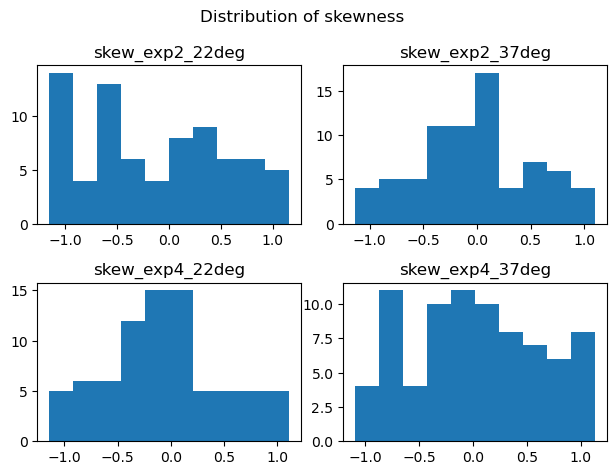

In [21]:
plot(2, 2, "Distribution of skewness", df, [["skew_exp2_22deg", "skew_exp2_37deg"], ["skew_exp4_22deg", "skew_exp4_37deg"]], 10)

# Principle component analysis

## Centering and scaling
- x scaled = (x - mean(x)) / std(x)

In [24]:
df_pca = df.filter(regex=r"^sum_exp\d+_\d+deg_\d+").T
scaler = StandardScaler()
df_pca_scaled = scaler.fit_transform(df_pca)

df_pca_scaled

array([[-0.60292041, -1.98267307, -0.47884738, ..., -1.5216238 ,
         0.91898797, -1.21257384],
       [-0.6112206 , -1.98267307, -0.90249574, ..., -1.06453856,
         0.91898797, -1.08706501],
       [-1.01046484, -1.98267307, -1.21571853, ..., -0.99509891,
         0.91898797, -1.20318663],
       ...,
       [ 1.38862453,  1.42724451,  0.91526624, ...,  0.77622986,
        -0.98157217,  0.95990955],
       [ 1.22193442,  0.26862135,  0.64070266, ...,  1.3333418 ,
        -0.98157217,  1.42467586],
       [ 0.5843323 ,  0.52831858,  0.51095617, ...,  0.67279625,
        -0.98157217,  0.72100004]], shape=(16, 90))

## PCA

In [25]:
pca = PCA(n_components=2)
scores = pca.fit_transform(df_pca_scaled)
scores

array([[ 8.73215894, -4.02473488],
       [ 8.77524133, -4.31832567],
       [ 8.68065705, -4.0538734 ],
       [ 6.63289405, -3.19531517],
       [ 6.53948218,  5.04294794],
       [ 7.06529177,  4.91667318],
       [ 6.56180737,  4.36908977],
       [ 5.93803367,  4.33870722],
       [-6.80036235, -4.20793887],
       [-7.09544794, -3.74076948],
       [-5.92015457, -3.38667665],
       [-7.5406255 , -4.16007129],
       [-7.31876701,  2.43553749],
       [-8.47596038,  3.7357284 ],
       [-8.57496528,  3.50713887],
       [-7.19928333,  2.74188252]])

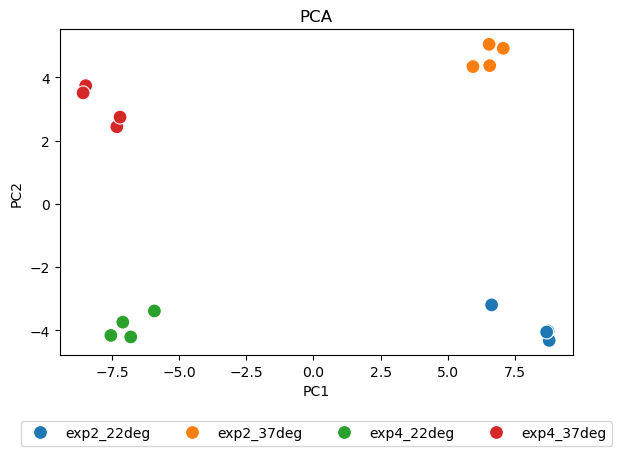

In [33]:
# PCA scores in DataFrame
df_pca_plot = pd.DataFrame(scores, columns=['PC1', 'PC2'])

# add groups
groups = ["exp2_22deg"]*4 + ["exp2_37deg"]*4 + ["exp4_22deg"]*4 + ["exp4_37deg"]*4
df_pca_plot['group'] = groups

# Plot
sns.scatterplot(data=df_pca_plot, x="PC1", y="PC2", hue="group", s=100)
plt.title("PCA")
plt.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.3))
plt.tight_layout()

# To Do
- enrichment analysis


# Notes

# Questions
- ttest depending on skewness?
- Sind exp2 und exp4 exakt gleich durchgeführt?
